# Vocabulary Inspection

Inspects the LDA vocabulary: document frequencies, `no_below`/`no_above` thresholds, alias-filtered tokens, and bigram candidates.

Richiede `spacy` e `en_core_web_sm`. Se non installati:
```
pip install spacy
python -m spacy download en_core_web_sm
```

In [ ]:
! pip install matplotlib
! pip install spacy
! pip install seaborn

In [2]:
import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

sns.set_context('talk')
%matplotlib inline

BASE_DIR = Path('.').resolve().parent
LDA_DIR  = BASE_DIR / 'data/topic_modeling'
CACHE    = LDA_DIR / 'vocab_cache.pkl'

print(f'Base dir: {BASE_DIR}')

Base dir: C:\Users\marco\Desktop\Reddit-tech-stocks-NLP-Topic_Modeling


## 1. Load chunks and tokenize with spaCy

Same pipeline as `01_build_corpus.py`: lemmatization, POS filtering, stopword removal, minimum token length 3.
Tokens are cached to `vocab_cache.pkl` so subsequent runs are fast.

In [3]:
ALLOWED_POS   = {'NOUN', 'VERB', 'ADJ', 'ADV'}
MIN_TOKEN_LEN = 3

if CACHE.exists():
    print('[INFO] Loading cached token lists...')
    with open(CACHE, 'rb') as f:
        token_lists = pickle.load(f)
    print(f'[INFO] Loaded {len(token_lists):,} documents from cache.')
else:
    print('[INFO] Cache not found — running spaCy preprocessing...')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

    df = pd.read_csv(BASE_DIR / 'data/corpus_building/chunks_lda_v1.csv', low_memory=False)
    texts = df['chunk_text'].astype(str).tolist()
    print(f'[INFO] Processing {len(texts):,} chunks...')

    token_lists = []
    batch_size  = 100
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        for doc in nlp.pipe(batch, batch_size=batch_size):
            tokens = [
                token.lemma_.lower()
                for token in doc
                if (
                    token.pos_ in ALLOWED_POS
                    and not token.is_stop
                    and not token.is_punct
                    and not token.is_space
                    and len(token.lemma_) >= MIN_TOKEN_LEN
                    and token.lemma_.isalpha()
                )
            ]
            token_lists.append(tokens)
        if i % 1000 == 0:
            print(f'  {min(i+batch_size, len(texts)):,}/{len(texts):,}')

    with open(CACHE, 'wb') as f:
        pickle.dump(token_lists, f)
    print(f'[INFO] Done. Cache saved -> {CACHE.name}')

print(f'Total tokens (raw): {sum(len(t) for t in token_lists):,}')
print(f'Documents:          {len(token_lists):,}')

[INFO] Loading cached token lists...
[INFO] Loaded 6,507 documents from cache.
Total tokens (raw): 1,658,601
Documents:          6,507


## 2. Document frequency (df) for each word

`df` = number of chunks in which the word appears at least once.

In [4]:
n_docs = len(token_lists)

df_counter = Counter()
for tokens in token_lists:
    for word in set(tokens):
        df_counter[word] += 1

df_series = pd.Series(df_counter, name='df').sort_values(ascending=False)
print(f'Unique tokens (no filter): {len(df_series):,}')
print(f'\nTop 30 by document frequency:')
print(df_series.head(30).to_string())

Unique tokens (no filter): 29,124

Top 30 by document frequency:
nvda       6399
buy        6326
call       6033
sell       5794
amd        5544
market     5446
put        5098
stock      5001
think      4967
get        4916
pltr       4829
day        4773
today      4608
money      4581
good       4575
time       4558
week       4371
fuck       4230
earning    4205
hold       4139
year       4045
look       3984
need       3979
share      3955
know       3926
right      3805
shit       3693
company    3685
pump       3595
price      3539


## 3. Effect of `no_below` and `no_above` thresholds

In [5]:
DICT_NO_ABOVE = 0.50
df_pct = df_series / n_docs

for no_below in [3, 5, 10, 15]:
    kept = df_series[(df_series >= no_below) & (df_pct <= DICT_NO_ABOVE)]
    print(f'no_below={no_below:2d}  →  {len(kept):5,} tokens in vocab  '
          f'(dropped low-freq: {(df_series < no_below).sum():,} | '
          f'dropped high-freq: {(df_pct > DICT_NO_ABOVE).sum():,})')

no_below= 3  →  12,032 tokens in vocab  (dropped low-freq: 17,057 | dropped high-freq: 35)
no_below= 5  →  9,096 tokens in vocab  (dropped low-freq: 19,993 | dropped high-freq: 35)
no_below=10  →  6,315 tokens in vocab  (dropped low-freq: 22,774 | dropped high-freq: 35)
no_below=15  →  5,094 tokens in vocab  (dropped low-freq: 23,995 | dropped high-freq: 35)


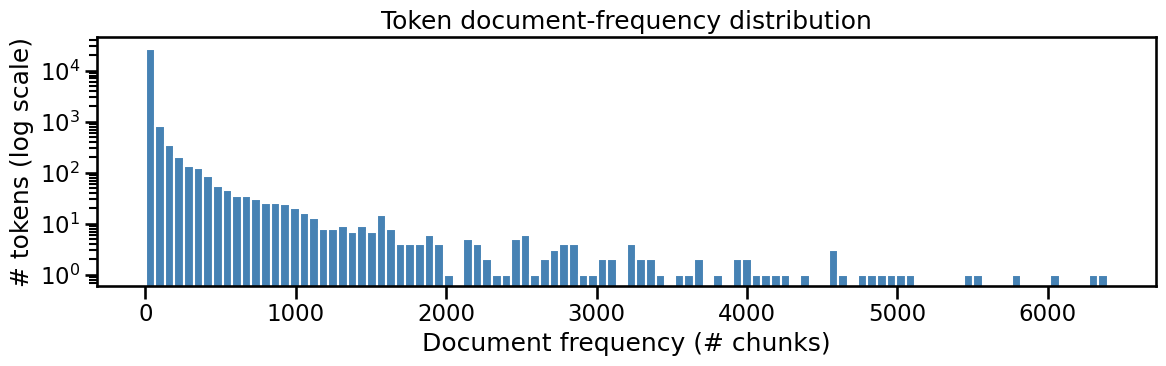

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_series.values, bins=100, log=True, color='steelblue', edgecolor='white')
ax.set_xlabel('Document frequency (# chunks)')
ax.set_ylabel('# tokens (log scale)')
ax.set_title('Token document-frequency distribution')
plt.tight_layout()
plt.show()

## 4. Alias stopwords — which words are filtered and how often

Filtered fields: `exact_tickers`, `company_names`, `safe_aliases`, `risky_aliases`.
Fields excluded from the filter: `context_keywords`, `notes`.

In [6]:
ALIAS_TARGET = {'NVDA', 'AMD', 'PLTR'}
# Fields to filter — context_keywords and notes are intentionally excluded
ALIAS_FIELDS = ('exact_tickers', 'company_names', 'safe_aliases', 'risky_aliases')

with open(BASE_DIR / 'config/alias_dictionary_v1.json') as f:
    alias_dict = json.load(f)

nlp_small = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

raw_alias_words = set()
for ticker, data in alias_dict.items():
    if ticker not in ALIAS_TARGET:
        continue
    for field in ALIAS_FIELDS:
        for entry in data.get(field, []):
            for word in entry.split():
                raw_alias_words.add(word.lower())

alias_stopwords = set()
for word in raw_alias_words:
    for token in nlp_small(word):
        alias_stopwords.add(token.lemma_.lower())
    alias_stopwords.add(word)

print(f'Alias stopwords ({len(alias_stopwords)}): {sorted(alias_stopwords)}')

Alias stopwords (31): [',', '.', 'advance', 'advanced', 'alex', 'amd', 'blackwell', 'corp', 'corporation', 'cuda', 'device', 'devices', 'devices,', 'epyc', 'gpu', 'gpus', 'huang', 'inc', 'inc.', 'jensen', 'karp', 'lisa', 'micro', 'nvda', 'nvidia', 'palantir', 'pltr', 'ryzen', 'su', 'technologies', 'technology']


In [7]:
alias_in_corpus = {
    w: df_series.get(w, 0)
    for w in alias_stopwords
    if df_series.get(w, 0) > 0
}
alias_df = pd.Series(alias_in_corpus, name='df').sort_values(ascending=False)
print('Alias tokens present in corpus (by document frequency):')
print(alias_df.to_string())

Alias tokens present in corpus (by document frequency):
nvda           6399
amd            5544
pltr           4829
palantir       2546
nvidia         1924
gpu            1023
advanced        665
jensen          516
technology      466
blackwell       327
cuda            294
gpus            270
advance         213
karp            176
device          116
corporation     109
ryzen            49
micro            45
epyc             20
corp             15
lisa             12
alex              8
inc               2
huang             2


## 5. Tokens removed by `no_above` (too frequent)

In [8]:
too_frequent = df_series[df_pct > DICT_NO_ABOVE].sort_values(ascending=False)
print(f'Tokens removed by no_above={DICT_NO_ABOVE} ({len(too_frequent)} tokens):')
print(too_frequent.to_string())

Tokens removed by no_above=0.5 (35 tokens):
nvda       6399
buy        6326
call       6033
sell       5794
amd        5544
market     5446
put        5098
stock      5001
think      4967
get        4916
pltr       4829
day        4773
today      4608
money      4581
good       4575
time       4558
week       4371
fuck       4230
earning    4205
hold       4139
year       4045
look       3984
need       3979
share      3955
know       3926
right      3805
shit       3693
company    3685
pump       3595
price      3539
say        3438
come       3364
open       3352
spy        3308
lol        3300


## 6. Possible Bigrams

Top bigram for raw frequency — to validate `BIGRAM_MIN_COUNT` e `BIGRAM_THRESHOLD`.

In [9]:
bigram_counter = Counter()
for tokens in token_lists:
    for i in range(len(tokens) - 1):
        bigram = f'{tokens[i]}_{tokens[i+1]}'
        bigram_counter[bigram] += 1

bigram_series = pd.Series(dict(bigram_counter), name='count').sort_values(ascending=False)
print('Top 50 bigram candidates (raw count):')
print(bigram_series.head(50).to_string())

Top 50 bigram candidates (raw count):
nvda_call       6397
buy_nvda        5684
nvda_earning    3272
sell_nvda       3040
nvda_put        2501
market_cap      2117
buy_amd         2080
amd_call        2074
pltr_put        1775
buy_call        1659
buy_pltr        1652
call_nvda       1374
pltr_call       1344
nvda_nvda       1317
buy_put         1304
long_term       1204
nvda_share      1169
think_nvda      1150
hold_nvda       1050
nvda_buy        1050
nvda_amd        1040
amd_nvda        1029
amd_put         1008
buy_dip          952
buy_share        941
nvda_chip        924
nvda_pump        916
lose_money       902
sell_amd         878
put_nvda         876
nvda_sell        858
sell_pltr        841
tsla_nvda        825
year_ago         806
need_nvda        800
free_money       751
nvda_hit         721
nvda_dip         720
today_nvda       712
stock_market     709
short_term       700
nvda_get         699
day_nvda         685
stock_price      675
datum_center     666
call_amd         

In [10]:
for min_count in [5, 10, 20, 50]:
    n = (bigram_series >= min_count).sum()
    print(f'BIGRAM_MIN_COUNT={min_count:2d}  →  {n:,} possible bigrams')

BIGRAM_MIN_COUNT= 5  →  46,269 possible bigrams
BIGRAM_MIN_COUNT=10  →  19,131 possible bigrams
BIGRAM_MIN_COUNT=20  →  8,076 possible bigrams
BIGRAM_MIN_COUNT=50  →  2,466 possible bigrams
